# 미니프로젝트: 차원 축소와 SHAP Value (Vibe Coding)

#### <목표>
오늘 배운 **mRMR, Boruta, SHAP Value**를 **통신사 고객 이탈(Customer Churn) 데이터셋**에 적용해 봅니다.

**Cursor AI**를 활용하여 각 단계의 코드를 직접 생성하고 실행해 보세요.

#### <데이터셋 소개>

| 변수명 | 설명 |
|:---:|:---|
| gender, SeniorCitizen, Partner, Dependents | 고객 인적사항 |
| tenure | 가입 개월 수 |
| PhoneService, MultipleLines, InternetService 등 | 가입 서비스 종류 |
| Contract, PaperlessBilling, PaymentMethod | 계약/결제 정보 |
| MonthlyCharges, TotalCharges | 월/누적 요금 |
| Churn | 이탈 여부 (Yes: 이탈, No: 유지) |

#### <실습 태스크>
| 태스크 | 타겟 변수 | 설명 |
|:---:|:---:|:---|
| 분류 | `Churn` | 인코딩된 고객 정보로 이탈 여부 예측 및 변수 해석 |

1. 각 섹션의 **과제**를 읽고, 어떤 고민/결정이 필요한지 먼저 생각해 봅니다.
2. 빈 코드 셀을 클릭한 후 Cursor AI 채팅창을 엽니다.
3. 막막한 부분은 AI와 상의해서 방법을 정하고, 그 방법으로 프롬프트를 작성합니다.
4. 생성된 코드를 실행하고 결과를 확인합니다.

## 0) 분석 준비

- `dataset/day5_miniproject.csv` 파일을 사용하기
- 타겟 변수: `Churn` (No: 유지, Yes: 이탈)
- 지난 미니프로젝트에서 다룬 전처리를 모두 적용한 뒤 시작하세요.

**[과제]** 써니는 어제 실습에서 사용한 통신사 고객 이탈(Churn) 데이터를 활용하여 분석을 진행하고자 합니다. 필요한 라이브러리와 데이터를 불러오세요.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["font.family"] = "Malgun Gothic"   # Windows 기본 한글 폰트
plt.rcParams["axes.unicode_minus"] = False       # 마이너스 기호 깨짐 방지

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

from sklearn.ensemble import RandomForestClassifier

# 평가 지표
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("dataset/day5_miniproject.csv")
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24.0,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72.0,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11.0,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4.0,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


**[과제]** 써니는 어제 진행한 통신사 고객 이탈 데이터 전처리 과정을 재사용하고자 합니다. Agent 기능을 활용하여 '머신러닝 Day4. 미니프로젝트.ipynb' 파일에서 전처리 코드를 찾아 실행하고 동일한 데이터 전처리 결과를 재현해 보세요.

> 입력변수, 출력변수 분할 / 학습 데이터, 테스트 데이터 분할 / 결측치 처리 / 스케일링, 인코딩

In [4]:
# Churn 타겟 변수 인코딩 (Yes: 1, No: 0)
data["Churn"] = data["Churn"].map({"Yes": 1, "No": 0})

# ── 0. Train/Test 분할 ────────────────────────────────────────
X = data.drop(columns="Churn")
y = data["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 1. 범주형 → 최빈값 대치 (train 기준) ─────────────────────
for col in ["InternetService", "PaymentMethod"]:
    mode_val = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode_val)
    X_test[col] = X_test[col].fillna(mode_val)

# ── 2. TotalCharges → 중앙값 대치 (train 기준) ───────────────
median_val = X_train["TotalCharges"].median()
X_train["TotalCharges"] = X_train["TotalCharges"].fillna(median_val)
X_test["TotalCharges"] = X_test["TotalCharges"].fillna(median_val)

# ── 3. tenure, MonthlyCharges → KNN Imputer (train 기준) ─────
knn_cols = ["tenure", "MonthlyCharges"]
imputer = KNNImputer(n_neighbors=5)
X_train[knn_cols] = imputer.fit_transform(X_train[knn_cols])
X_test[knn_cols] = imputer.transform(X_test[knn_cols])

print("결측치 처리 후:")
print(
    X_train[
        ["tenure", "InternetService", "PaymentMethod", "MonthlyCharges", "TotalCharges"]
    ].isnull().sum()
)

# ── 4. Label Encoding (이진 범주형) ──────────────────────────
binary_map = {
    "gender": {"Male": 1, "Female": 0},
    "Partner": {"Yes": 1, "No": 0},
    "Dependents": {"Yes": 1, "No": 0},
    "PhoneService": {"Yes": 1, "No": 0},
    "PaperlessBilling": {"Yes": 1, "No": 0},
}
for col, mapping in binary_map.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

# ── 5. One-Hot Encoding (다중 범주형) ──────────────────────
ohe_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod",
]

X_train = pd.get_dummies(X_train, columns=ohe_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=ohe_cols, drop_first=False)

# train/test 컬럼 불일치 보정
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# ── 6. StandardScaler (수치형) ───────────────────────────────
scale_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

print(f"\n전처리 완료 - X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train 분포:\n{y_train.value_counts()}")

결측치 처리 후:
tenure             0
InternetService    0
PaymentMethod      0
MonthlyCharges     0
TotalCharges       0
dtype: int64

전처리 완료 - X_train: (5634, 40), X_test: (1409, 40)
y_train 분포:
Churn
0    4139
1    1495
Name: count, dtype: int64


## 1) 다중공선성 확인

**[과제]** 써니는 인코딩된 변수들의 상관행렬을 히트맵으로 그려보고 어떤 변수끼리 상관관계가 높은지 AI와 함께 확인해 보세요.

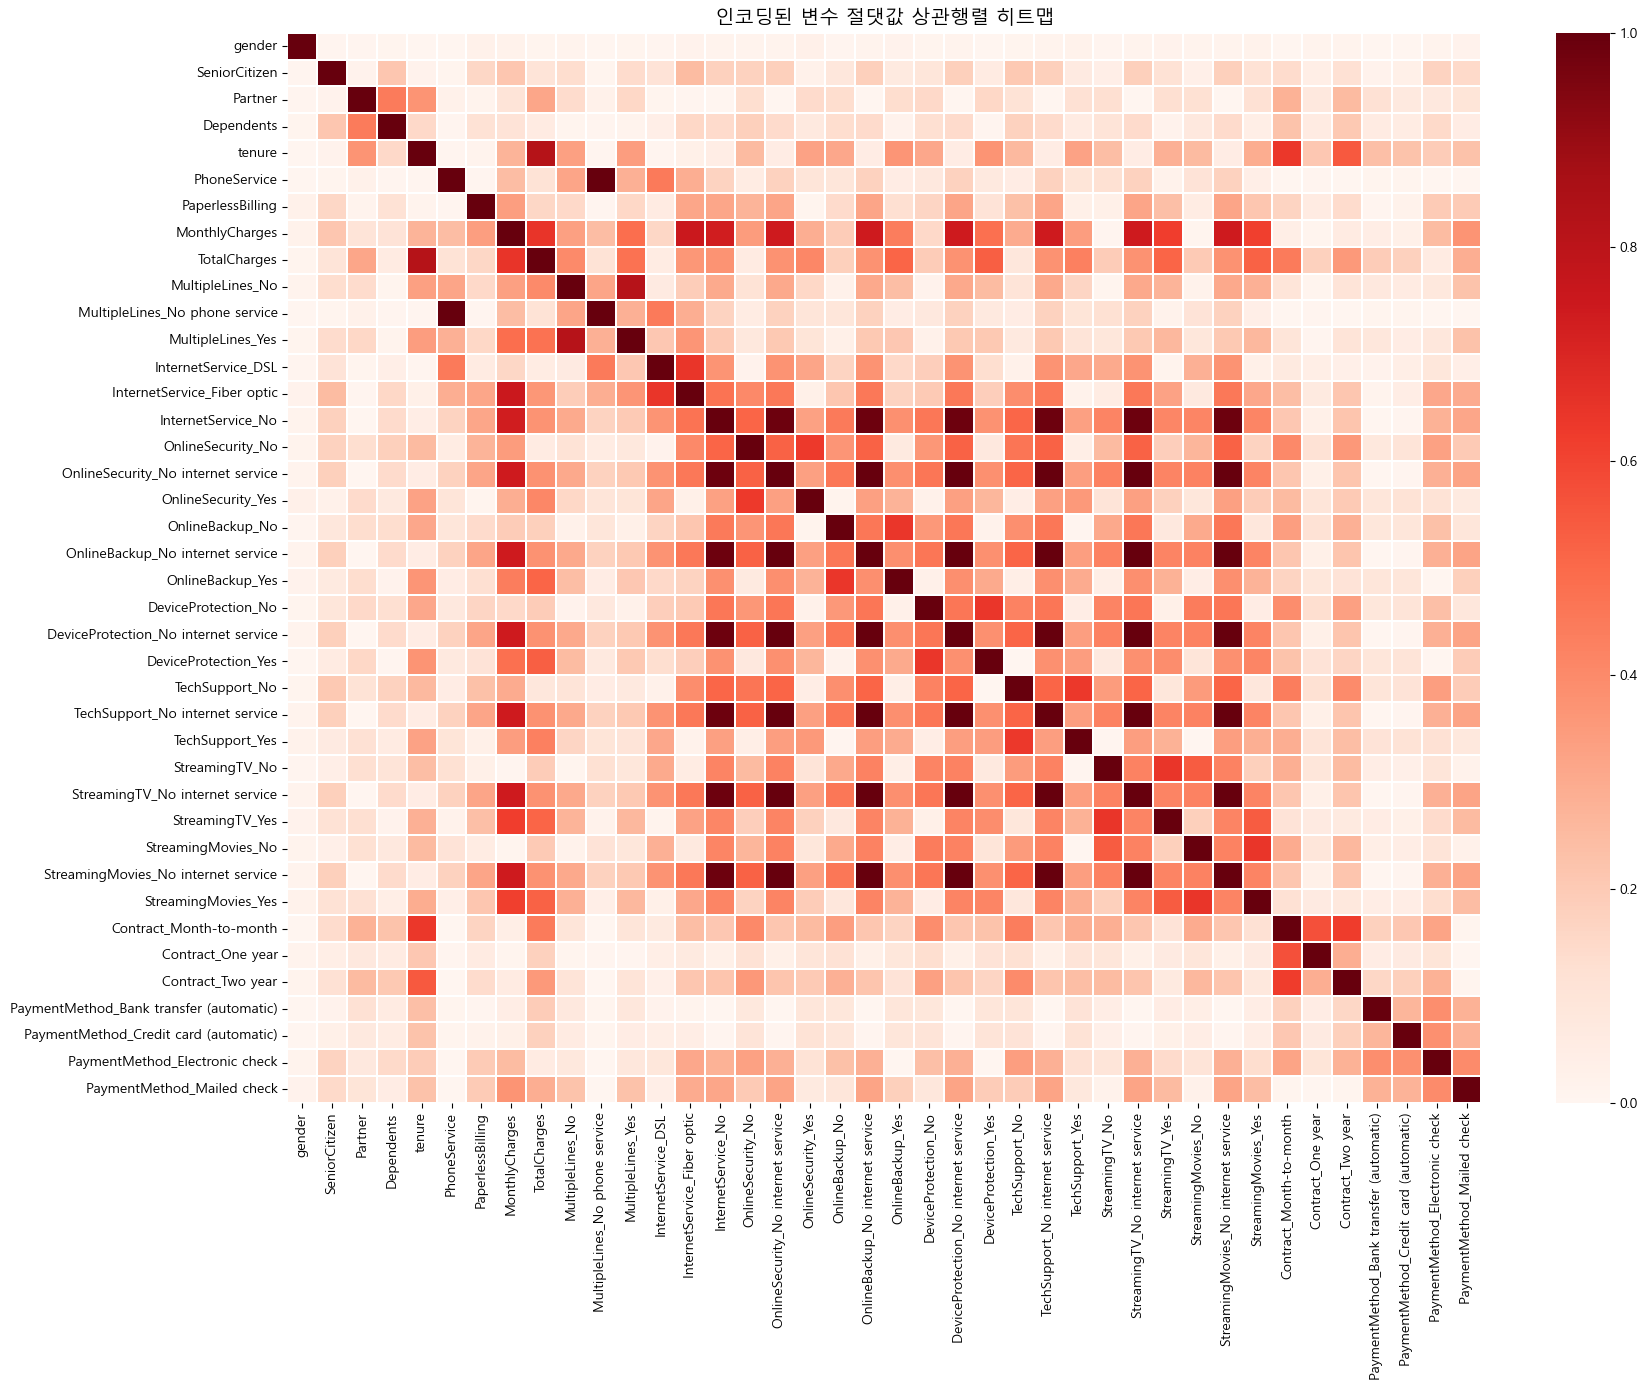

In [6]:
plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix.abs(),
    cmap="Reds",
    vmin=0,
    vmax=1,
    linewidths=0.3,
)
plt.title("인코딩된 변수 절댓값 상관행렬 히트맵", fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [8]:
# 상관계수 절댓값 기준 (보통 0.7 이상이면 다중공선성 의심)
threshold = 0.7

# 상삼각 행렬만 사용해 중복 쌍 제거
corr_pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["변수1", "변수2", "상관계수(절댓값)"]

# 임계값 이상만 필터링 후 정렬
high_corr = (
    corr_pairs[corr_pairs["상관계수(절댓값)"] >= threshold]
    .sort_values("상관계수(절댓값)", ascending=False)
    .reset_index(drop=True)
)

print(f"상관계수 절댓값 {threshold} 이상인 변수 쌍: {len(high_corr)}개")
display(high_corr)

상관계수 절댓값 0.7 이상인 변수 쌍: 32개


,변수1,변수2,상관계수(절댓값)
0,OnlineBackup_No internet service,StreamingTV_No internet service,1.000000
1,StreamingTV_No internet service,StreamingMovies_No internet service,1.000000
2,TechSupport_No internet service,StreamingTV_No internet service,1.000000
3,TechSupport_No internet service,StreamingMovies_No internet service,1.000000
4,DeviceProtection_No internet service,StreamingTV_No internet service,1.000000
5,DeviceProtection_No internet service,TechSupport_No internet service,1.000000
6,OnlineBackup_No internet service,StreamingMovies_No internet service,1.000000
7,DeviceProtection_No internet service,StreamingMovies_No internet service,1.000000
8,OnlineSecurity_No internet service,StreamingTV_No internet service,1.000000
9,OnlineBackup_No internet service,TechSupport_No internet service,1.000000


In [9]:
# 원본 상관계수(부호 포함)도 함께 확인
signed_corr = []
for _, row in high_corr.iterrows():
    v1, v2 = row["변수1"], row["변수2"]
    signed_corr.append(corr_matrix.loc[v1, v2])

high_corr["상관계수(부호 포함)"] = signed_corr
display(high_corr)

,변수1,변수2,상관계수(절댓값),상관계수(부호 포함)
0,OnlineBackup_No internet service,StreamingTV_No internet service,1.000000,1.000000
1,StreamingTV_No internet service,StreamingMovies_No internet service,1.000000,1.000000
2,TechSupport_No internet service,StreamingTV_No internet service,1.000000,1.000000
3,TechSupport_No internet service,StreamingMovies_No internet service,1.000000,1.000000
4,DeviceProtection_No internet service,StreamingTV_No internet service,1.000000,1.000000
5,DeviceProtection_No internet service,TechSupport_No internet service,1.000000,1.000000
6,OnlineBackup_No internet service,StreamingMovies_No internet service,1.000000,1.000000
7,DeviceProtection_No internet service,StreamingMovies_No internet service,1.000000,1.000000
8,OnlineSecurity_No internet service,StreamingTV_No internet service,1.000000,1.000000
9,OnlineBackup_No internet service,TechSupport_No internet service,1.000000,1.000000


**[과제]** 써니는 변수 선택법과 SHAP 분석을 적용하기 전에 전체 변수를 사용한 Random Forest 분류 모델의 성능을 기준으로 삼고자 합니다. AI와 상의하여 모델을 학습하고, Accuracy, Precision, Recall, F1-score를 계산하여 성능을 확인하는 코드를 작성해 보세요.

In [15]:
# 전체 변수를 사용한 Random Forest 베이스라인 모델
rf_all = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

rf_all.fit(X_train, y_train)
print(f"학습 완료 | 사용 변수 수: {X_train.shape[1]}")

학습 완료 | 사용 변수 수: 40


In [54]:
# 분류 성능 평가 함수
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print("혼동행렬")
    print(confusion_matrix(real, pred))
    print()

# 테스트 데이터 예측 및 성능 평가
y_pred_all = rf_all.predict(X_test)

print("=== 전체 변수 Random Forest 성능 (테스트셋) ===")
get_classscore(y_test, y_pred_all)

=== 전체 변수 Random Forest 성능 (테스트셋) ===
Accuracy  : 0.774
Precision : 0.593
Recall    : 0.476
F1-score  : 0.528
혼동행렬
[[913 122]
 [196 178]]



In [17]:
baseline_scores = pd.DataFrame({
    "지표": ["Accuracy", "Precision", "Recall", "F1-score"],
    "값": [
        accuracy_score(y_test, y_pred_all),
        precision_score(y_test, y_pred_all),
        recall_score(y_test, y_pred_all),
        f1_score(y_test, y_pred_all),
    ],
})
baseline_scores["값"] = baseline_scores["값"].round(4)
baseline_scores

,지표,값
0,Accuracy,0.7743
1,Precision,0.5933
2,Recall,0.4759
3,F1-score,0.5282


## 2) mRMR 변수 선택

**[과제]** 써니는 mRMR을 활용해 중요한 변수를 선택해보고자 합니다. AI와 상의해서 가장 적합한 k를 결정하고 선택된 변수로 모델을 다시 학습시켜 전체 변수를 사용했을 때 때와 성능을 비교해 보세요.

In [21]:
!pip install mrmr-selection

In [55]:
from mrmr import mrmr_classif
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

# k 후보 (전체 변수 수 이하로 설정)
k_candidates = [k for k in [5, 7, 10, 12, 15, 20, 25, 30] if k <= X_train.shape[1]]
print("k 후보:", k_candidates)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
k_scores = {}

for k in k_candidates:
    # 학습 데이터 전체 기준 mRMR 변수 선택 (Day 5-1 방식)
    selected = mrmr_classif(X=X_train, y=y_train, K=k)

    fold_scores = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr = X_train.iloc[train_idx][selected]
        X_val = X_train.iloc[val_idx][selected]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        fold_scores.append(f1_score(y_val, pred))

    k_scores[k] = np.mean(fold_scores)
    print(f"k={k:2d} | 선택 변수 수={len(selected)} | 평균 F1-score={k_scores[k]:.4f}")

k 후보: [5, 7, 10, 12, 15, 20, 25, 30]


100%|██████████| 5/5 [00:00<00:00, 26.26it/s]


k= 5 | 선택 변수 수=5 | 평균 F1-score=0.5488


100%|██████████| 7/7 [00:00<00:00, 24.92it/s]


k= 7 | 선택 변수 수=7 | 평균 F1-score=0.5362


...

k=20 | 선택 변수 수=20 | 평균 F1-score=0.5269


100%|██████████| 25/25 [00:00<00:00, 28.28it/s]


k=25 | 선택 변수 수=25 | 평균 F1-score=0.5235


100%|██████████| 30/30 [00:01<00:00, 25.20it/s]


k=30 | 선택 변수 수=30 | 평균 F1-score=0.5428


In [56]:
# F1-score가 가장 높은 k 선택
best_k = max(k_scores, key=k_scores.get)
print(f"\n최적 k: {best_k} (평균 F1-score={k_scores[best_k]:.4f})")


최적 k: 5 (평균 F1-score=0.5488)


In [57]:
selected_mrmr = mrmr_classif(X=X_train, y=y_train, K=best_k)
removed_mrmr = [col for col in X_train.columns if col not in selected_mrmr]

print(f"mRMR 선택 변수 ({len(selected_mrmr)}개):")
print(selected_mrmr)
print(f"\n제거된 변수: {len(removed_mrmr)}개 (전체 {X_train.shape[1]}개 중 {len(selected_mrmr)}개 사용)")

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 35.94it/s]

mRMR 선택 변수 (5개):
['Contract_Month-to-month', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'InternetService_DSL', 'TechSupport_No']

제거된 변수: 35개 (전체 40개 중 5개 사용)


## 3) Boruta 변수 선택

**[과제]** 써니는 Boruta로도 변수를 선택해보고자 합니다. AI와 상의하여 관련 코드를 작성하세요.

In [18]:
!pip install boruta

In [19]:
from boruta import BorutaPy
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score

# 분류 문제이므로 RandomForestClassifier 사용 (Day 5-1은 Regressor)
rf_boruta = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)

boruta_selector = BorutaPy(
    rf_boruta,
    n_estimators="auto",
    max_iter=50,        # 변수 많으면 50~100 권장 (수렴할 때까지)
    perc=100,
    random_state=42,
)

# BorutaPy는 numpy 배열만 지원
boruta_selector.fit(X_train.values, y_train.values.ravel())

print("Boruta 확정 변수 수:", boruta_selector.n_features_)

Boruta 확정 변수 수: 4


In [20]:
# 확정(Selected) / 미정(Tentative) / 기각(Rejected) 구분
boruta_cols = X_train.columns[boruta_selector.support_].tolist()
boruta_tentative = X_train.columns[boruta_selector.support_weak_].tolist()
boruta_rejected = X_train.columns[
    ~boruta_selector.support_ & ~boruta_selector.support_weak_
].tolist()

print(f"확정 변수 ({len(boruta_cols)}개):", boruta_cols)
print(f"미정 변수 ({len(boruta_tentative)}개):", boruta_tentative)
print(f"기각 변수 ({len(boruta_rejected)}개)")

확정 변수 (4개): ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month']
미정 변수 (0개): []
기각 변수 (36개)


## 4) 성능 비교 요약

**[과제]** 써니는 전체 변수/mRMR/Boruta 세 가지 방법의 성능을 표로 정리하고 변수 수를 줄였을 때 성능이 어떻게 변하는지 AI와 함께 해석해 보세요.

In [26]:
def get_classscore(real, pred):
    print("Accuracy  : %.3f" % accuracy_score(real, pred))
    print("Precision : %.3f" % precision_score(real, pred))
    print("Recall    : %.3f" % recall_score(real, pred))
    print("F1-score  : %.3f" % f1_score(real, pred))
    print("혼동행렬")
    print(confusion_matrix(real, pred))  # real, pred 사용
    print()

rf_all = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)

print("=== 1) 전체 변수 ===")
print(f"변수 수: {X_train.shape[1]}")
get_classscore(y_test, y_pred_all)

=== 1) 전체 변수 ===
변수 수: 40
Accuracy  : 0.774
Precision : 0.593
Recall    : 0.476
F1-score  : 0.528
혼동행렬
[[913 122]
 [196 178]]



In [27]:
rf_mrmr = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_mrmr.fit(X_train[selected_mrmr], y_train)
y_pred_mrmr = rf_mrmr.predict(X_test[selected_mrmr])

print(f"=== 2) mRMR (k={best_k}) ===")
print(f"변수 수: {len(selected_mrmr)}")
print(f"선택 변수: {selected_mrmr}")
get_classscore(y_test, y_pred_mrmr)

=== 2) mRMR (k=5) ===
변수 수: 5
선택 변수: ['Contract_Month-to-month', 'PaymentMethod_Mailed check', 'OnlineSecurity_No', 'InternetService_DSL', 'TechSupport_No']
Accuracy  : 0.776
Precision : 0.595
Recall    : 0.495
F1-score  : 0.540
혼동행렬
[[909 126]
 [189 185]]



In [28]:
selected_boruta_final = boruta_cols  # 미정 변수 0개

rf_boruta_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_boruta_model.fit(X_train[selected_boruta_final], y_train)
y_pred_boruta = rf_boruta_model.predict(X_test[selected_boruta_final])

print("=== 3) Boruta ===")
print(f"변수 수: {len(selected_boruta_final)}")
print(f"선택 변수: {selected_boruta_final}")
get_classscore(y_test, y_pred_boruta)

=== 3) Boruta ===
변수 수: 4
선택 변수: ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract_Month-to-month']
Accuracy  : 0.754
Precision : 0.545
Recall    : 0.452
F1-score  : 0.494
혼동행렬
[[894 141]
 [205 169]]



In [29]:
results = pd.DataFrame({
    "방법": ["전체 변수", f"mRMR (k={best_k})", "Boruta"],
    "변수 수": [X_train.shape[1], len(selected_mrmr), len(selected_boruta_final)],
    "Accuracy": [
        accuracy_score(y_test, y_pred_all),
        accuracy_score(y_test, y_pred_mrmr),
        accuracy_score(y_test, y_pred_boruta),
    ],
    "Precision": [
        precision_score(y_test, y_pred_all),
        precision_score(y_test, y_pred_mrmr),
        precision_score(y_test, y_pred_boruta),
    ],
    "Recall": [
        recall_score(y_test, y_pred_all),
        recall_score(y_test, y_pred_mrmr),
        recall_score(y_test, y_pred_boruta),
    ],
    "F1-score": [
        f1_score(y_test, y_pred_all),
        f1_score(y_test, y_pred_mrmr),
        f1_score(y_test, y_pred_boruta),
    ],
}).round(4)

results

,방법,변수 수,Accuracy,Precision,Recall,F1-score
0,전체 변수,40,0.7743,0.5933,0.4759,0.5282
1,mRMR (k=5),5,0.7764,0.5949,0.4947,0.5401
2,Boruta,4,0.7544,0.5452,0.4519,0.4942


In [30]:
# F1-score 기준 최적 모델 선택
best_idx = results["F1-score"].idxmax()
best_method = results.loc[best_idx, "방법"]

print(f"최적 모델: {best_method}")
print(f"F1-score: {results.loc[best_idx, 'F1-score']}")
print(f"변수 수: {results.loc[best_idx, '변수 수']}")

# SHAP 분석용 모델 저장
if best_method == "전체 변수":
    best_model = rf_all
    best_X_test = X_test
elif "mRMR" in best_method:
    best_model = rf_mrmr
    best_X_test = X_test[selected_mrmr]
else:
    best_model = rf_boruta_model
    best_X_test = X_test[selected_boruta_final]

최적 모델: mRMR (k=5)
F1-score: 0.5401
변수 수: 5


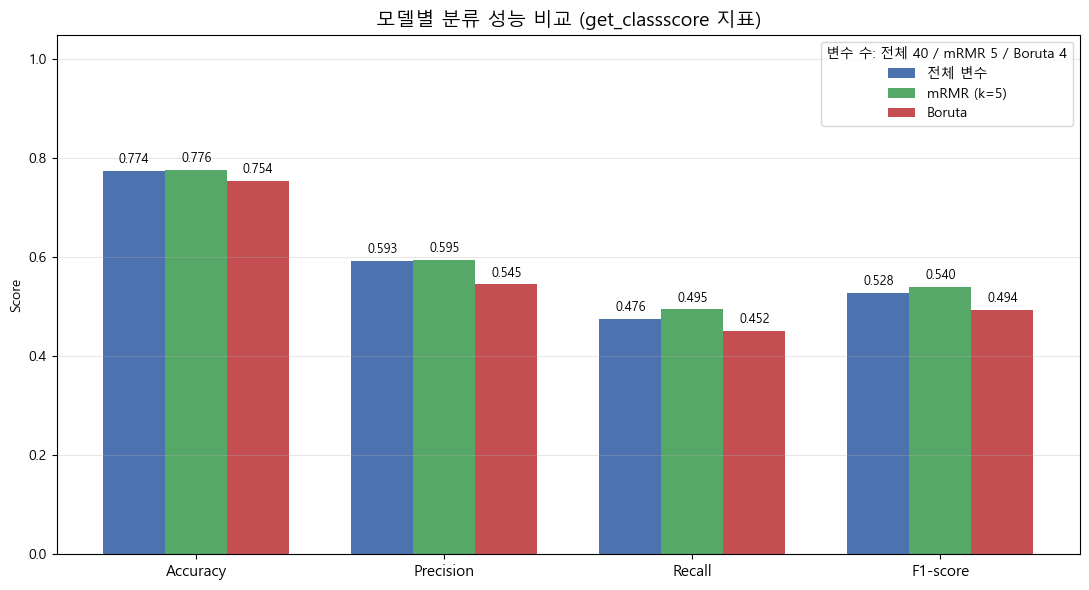

In [32]:
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
methods = results["방법"].tolist()

x = np.arange(len(metrics))
width = 0.25
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(11, 6))

for i, method in enumerate(methods):
    values = results.loc[i, metrics].values
    bars = ax.bar(x + (i - 1) * width, values, width, label=method, color=colors[i])
    
    # 막대 위에 수치 표시
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("모델별 분류 성능 비교 (get_classscore 지표)", fontsize=14)
ax.legend(title=f"변수 수: 전체 {X_train.shape[1]} / mRMR {len(selected_mrmr)} / Boruta {len(boruta_cols)}")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5) SHAP Value로 이탈 요인 해석

**[과제]** 써니는 성능이 가장 좋았던 모델에 대해 SHAP TreeExplainer를 적용하고 Summary Plot으로 이탈에 가장 큰 영향을 미치는 변수 상위 10개를 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [33]:
!pip install shap

In [35]:
# ── F1-score 기준 Best Model 선택 ─────────────────────────────
best_idx = results["F1-score"].idxmax()
best_method = results.loc[best_idx, "방법"]

if best_method == "전체 변수":
    best_model = rf_all
    X_shap = X_train
elif "mRMR" in best_method:
    best_model = rf_mrmr
    X_shap = X_train[selected_mrmr]
else:
    best_model = rf_boruta_model
    X_shap = X_train[selected_boruta_final]

print(f"Best Model: {best_method}")
print(f"사용 변수 수: {X_shap.shape[1]}")

# ── SHAP TreeExplainer ───────────────────────────────────────
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# 이탈(Churn=1) 클래스 SHAP 값 추출
if isinstance(shap_values, list):
    shap_churn = shap_values[1]          # [0]=유지, [1]=이탈
else:
    shap_churn = shap_values[:, :, 1]    # 3차원 배열인 경우

print(f"SHAP 값 shape: {shap_churn.shape}")

Best Model: mRMR (k=5)
사용 변수 수: 5
SHAP 값 shape: (5634, 5)


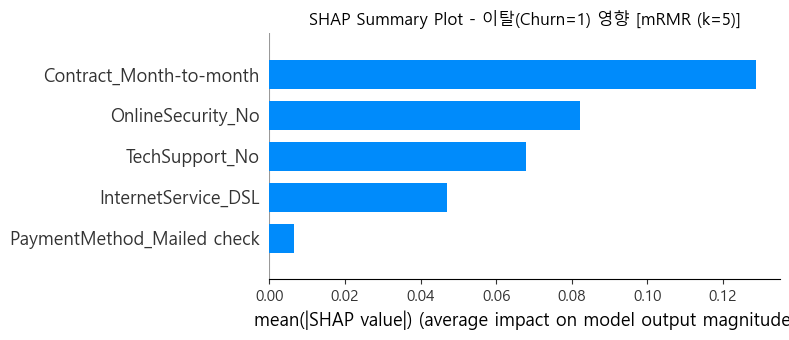

In [36]:
# 막대 Summary Plot (변수 중요도 순)
shap.summary_plot(
    shap_churn,
    X_shap,
    plot_type="bar",
    max_display=10,
    show=False,
)
plt.title(f"SHAP Summary Plot - 이탈(Churn=1) 영향 [{best_method}]")
plt.tight_layout()
plt.show()

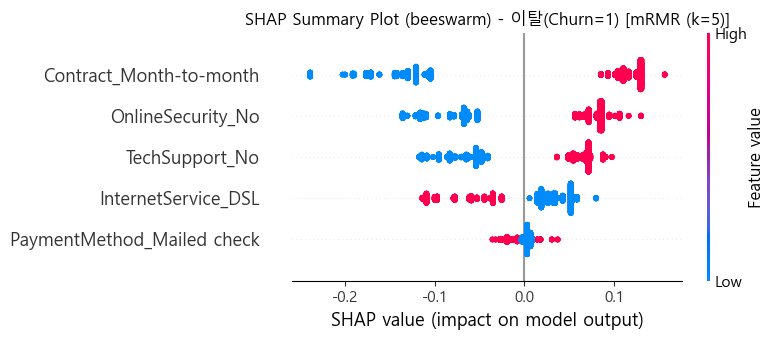

In [37]:
# beeswarm Summary Plot (값 크기·방향까지 확인)
shap.summary_plot(
    shap_churn,
    X_shap,
    max_display=10,
    show=False,
)
plt.title(f"SHAP Summary Plot (beeswarm) - 이탈(Churn=1) [{best_method}]")
plt.tight_layout()
plt.show()

**[과제]** 써니는 실제로 이탈(Churn=1)로 예측된 고객 한 명을 골라서 Force Plot으로 어떤 변수들이 이탈 예측에 기여했는지 확인해보고자 합니다. AI를 활용해 관련 코드를 작성해보세요.

In [42]:
# Best Model에 맞는 테스트 데이터 준비
if best_method == "전체 변수":
    X_test_best = X_test
elif "mRMR" in best_method:
    X_test_best = X_test[selected_mrmr]
else:
    X_test_best = X_test[selected_boruta_final]

# 이탈(1)로 예측된 고객 인덱스 찾기
y_pred_best = best_model.predict(X_test_best)
churn_pred_idx = np.where(y_pred_best == 1)[0]

print(f"테스트셋에서 이탈로 예측된 고객 수: {len(churn_pred_idx)}명")

# 첫 번째 고객 선택 (다른 고객 보려면 [0] → [1], [2] 등으로 변경)
sample_idx = churn_pred_idx[1]
sample_X = X_test_best.iloc[[sample_idx]]

print(f"\n선택 고객 (테스트셋 index): {sample_idx}")
print(f"실제 Churn: {y_test.iloc[sample_idx]} ({'이탈' if y_test.iloc[sample_idx]==1 else '유지'})")
print(f"예측 Churn: {y_pred_best[sample_idx]} ({'이탈' if y_pred_best[sample_idx]==1 else '유지'})")
print(f"이탈 확률: {best_model.predict_proba(sample_X)[0][1]:.3f}")

테스트셋에서 이탈로 예측된 고객 수: 311명

선택 고객 (테스트셋 index): 13
실제 Churn: 1 (이탈)
예측 Churn: 1 (이탈)
이탈 확률: 0.607


In [ ]:
churn_pred_idx

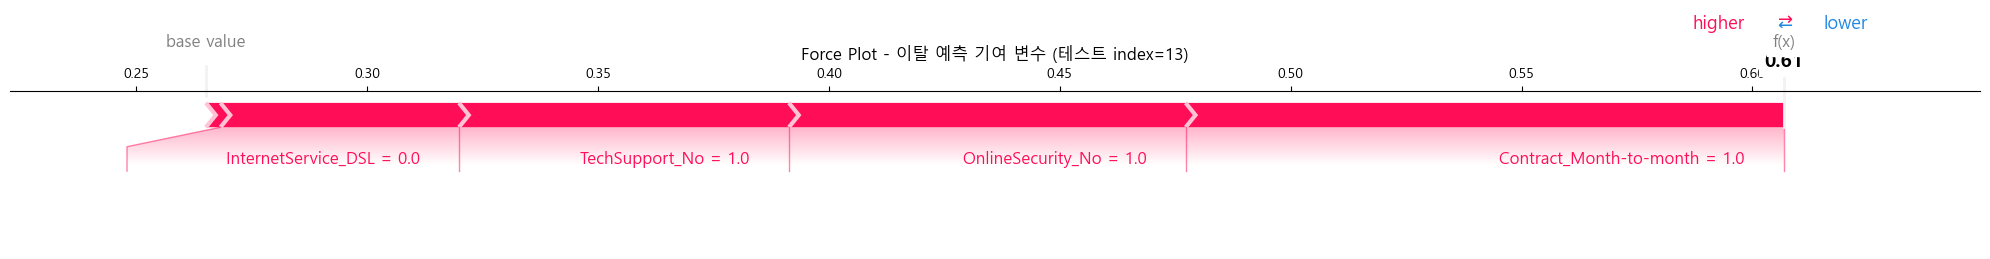

In [43]:
# 선택 고객의 SHAP 값 계산
shap_values_sample = explainer.shap_values(sample_X)

# 이탈(클래스 1) 기준 SHAP 추출
if isinstance(shap_values_sample, list):
    expected_value = explainer.expected_value[1]
    shap_sample = shap_values_sample[1][0]
else:
    expected_value = explainer.expected_value[1]
    shap_sample = shap_values_sample[0, :, 1]

# Force Plot
shap.force_plot(
    expected_value,
    shap_sample,
    sample_X.iloc[0],
    matplotlib=True,
    show=False,
)
plt.title(f"Force Plot - 이탈 예측 기여 변수 (테스트 index={sample_idx})")
plt.tight_layout()
plt.show()

In [44]:
# mRMR + Boruta 확정 변수 합치기 (중복 제거)
selected_combined = list(set(selected_mrmr + boruta_cols))
selected_combined.sort()

print(f"통합 변수 ({len(selected_combined)}개):")
print(selected_combined)

# 학습 / 테스트 데이터
X_train_comb = X_train[selected_combined]
X_test_comb  = X_test[selected_combined]

# Random Forest 학습
rf_combined = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
)
rf_combined.fit(X_train_comb, y_train)

# 예측 및 성능 평가
y_pred_comb = rf_combined.predict(X_test_comb)

print("\n=== mRMR + Boruta 통합 변수 Random Forest 성능 (테스트셋) ===")
get_classscore(y_test, y_pred_comb)

통합 변수 (8개):
['Contract_Month-to-month', 'InternetService_DSL', 'MonthlyCharges', 'OnlineSecurity_No', 'PaymentMethod_Mailed check', 'TechSupport_No', 'TotalCharges', 'tenure']

=== mRMR + Boruta 통합 변수 Random Forest 성능 (테스트셋) ===
Accuracy  : 0.773
Precision : 0.589
Recall    : 0.479
F1-score  : 0.528
혼동행렬
[[910 125]
 [195 179]]



In [45]:
compare_upgrade = pd.DataFrame({
    "방법": ["전체 변수", f"mRMR (k={best_k})", "Boruta", "mRMR+Boruta 통합"],
    "변수 수": [X_train.shape[1], len(selected_mrmr), len(boruta_cols), len(selected_combined)],
    "Accuracy": [
        accuracy_score(y_test, y_pred_all),
        accuracy_score(y_test, y_pred_mrmr),
        accuracy_score(y_test, y_pred_boruta),
        accuracy_score(y_test, y_pred_comb),
    ],
    "Precision": [
        precision_score(y_test, y_pred_all),
        precision_score(y_test, y_pred_mrmr),
        precision_score(y_test, y_pred_boruta),
        precision_score(y_test, y_pred_comb),
    ],
    "Recall": [
        recall_score(y_test, y_pred_all),
        recall_score(y_test, y_pred_mrmr),
        recall_score(y_test, y_pred_boruta),
        recall_score(y_test, y_pred_comb),
    ],
    "F1-score": [
        f1_score(y_test, y_pred_all),
        f1_score(y_test, y_pred_mrmr),
        f1_score(y_test, y_pred_boruta),
        f1_score(y_test, y_pred_comb),
    ],
}).round(4)

display(compare_upgrade)

,방법,변수 수,Accuracy,Precision,Recall,F1-score
0,전체 변수,40,0.7743,0.5933,0.4759,0.5282
1,mRMR (k=5),5,0.7764,0.5949,0.4947,0.5401
2,Boruta,4,0.7544,0.5452,0.4519,0.4942
3,mRMR+Boruta 통합,8,0.7729,0.5888,0.4786,0.5280


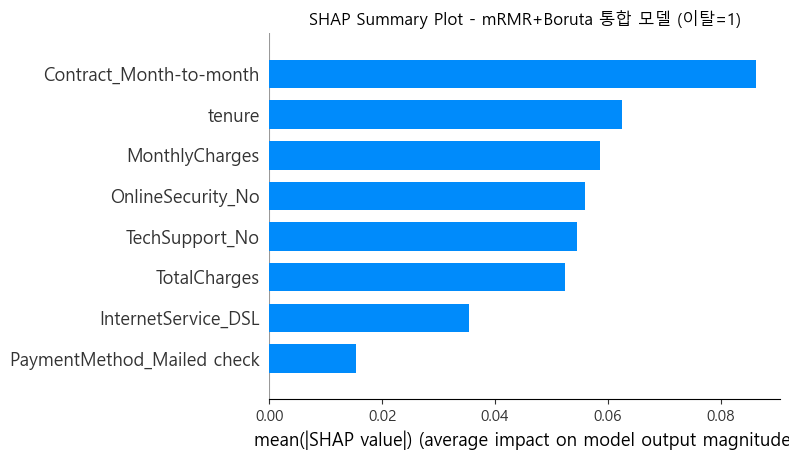

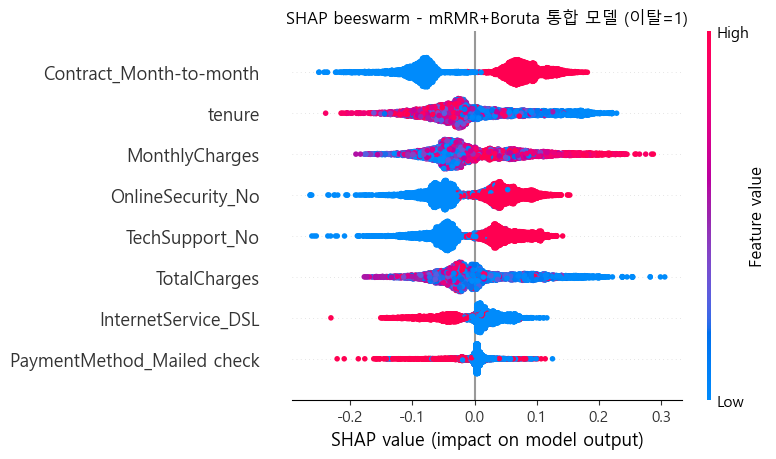

In [46]:
# TreeExplainer
explainer_comb = shap.TreeExplainer(rf_combined)
shap_values_comb = explainer_comb.shap_values(X_train_comb)

# 이탈(Churn=1) 클래스 SHAP
if isinstance(shap_values_comb, list):
    shap_churn_comb = shap_values_comb[1]
    expected_value_comb = explainer_comb.expected_value[1]
else:
    shap_churn_comb = shap_values_comb[:, :, 1]
    expected_value_comb = explainer_comb.expected_value[1]

# Summary Plot (bar) - 이탈 영향력 상위 변수
shap.summary_plot(
    shap_churn_comb,
    X_train_comb,
    plot_type="bar",
    max_display=len(selected_combined),
    show=False,
)
plt.title("SHAP Summary Plot - mRMR+Boruta 통합 모델 (이탈=1)")
plt.tight_layout()
plt.show()

# beeswarm (값 분포까지 확인)
shap.summary_plot(
    shap_churn_comb,
    X_train_comb,
    max_display=len(selected_combined),
    show=False,
)
plt.title("SHAP beeswarm - mRMR+Boruta 통합 모델 (이탈=1)")
plt.tight_layout()
plt.show()

In [47]:
shap_df_comb = (
    pd.DataFrame({
        "변수": X_train_comb.columns,
        "평균_|SHAP|": np.abs(shap_churn_comb).mean(axis=0),
    })
    .sort_values("평균_|SHAP|", ascending=False)
    .reset_index(drop=True)
)
shap_df_comb["순위"] = shap_df_comb.index + 1
display(shap_df_comb)

,변수,평균_|SHAP|,순위
0,Contract_Month-to-month,0.086200,1
1,tenure,0.062468,2
2,MonthlyCharges,0.058633,3
3,OnlineSecurity_No,0.055875,4
4,TechSupport_No,0.054542,5
5,TotalCharges,0.052464,6
6,InternetService_DSL,0.035414,7
7,PaymentMethod_Mailed check,0.015301,8


선택 고객 (테스트 index): 20
실제 Churn: 1 (이탈)
예측 Churn: 1
이탈 확률: 0.560


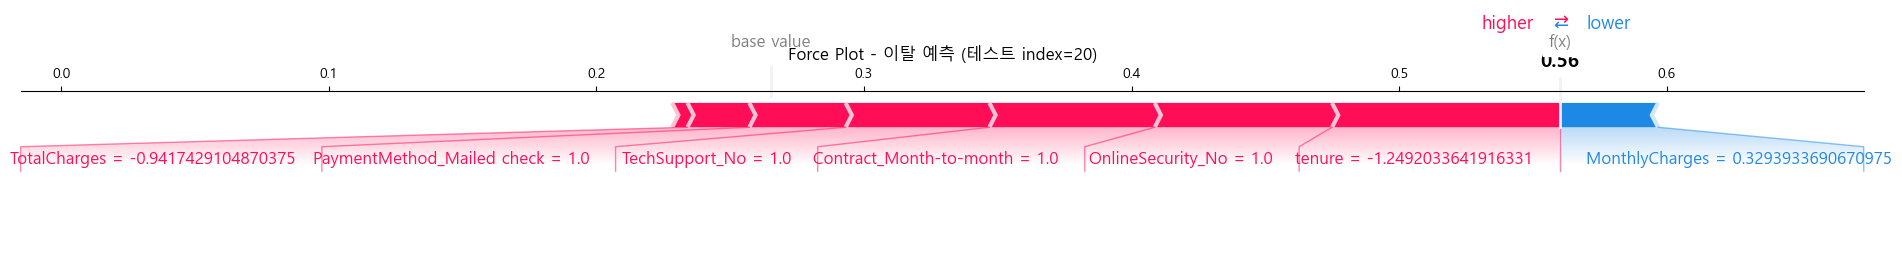

,변수,값,SHAP
7,tenure,-1.249203,0.085100
3,OnlineSecurity_No,True,0.066269
0,Contract_Month-to-month,True,0.061769
5,TechSupport_No,True,0.053729
2,MonthlyCharges,0.329393,-0.036751
4,PaymentMethod_Mailed check,True,0.035969
6,TotalCharges,-0.941743,0.023125
1,InternetService_DSL,False,0.005703


In [53]:
# 테스트셋에서 이탈(1)로 예측된 고객 1명 선택
churn_pred_idx = np.where(y_pred_comb == 1)[0]
sample_idx = churn_pred_idx[3]
sample_X = X_test_comb.iloc[[sample_idx]]

print(f"선택 고객 (테스트 index): {sample_idx}")
print(f"실제 Churn: {y_test.iloc[sample_idx]} ({'이탈' if y_test.iloc[sample_idx]==1 else '유지'})")
print(f"예측 Churn: {y_pred_comb[sample_idx]}")
print(f"이탈 확률: {rf_combined.predict_proba(sample_X)[0][1]:.3f}")

# 해당 고객 SHAP 값
shap_sample = explainer_comb.shap_values(sample_X)
if isinstance(shap_sample, list):
    sv = shap_sample[1][0]
else:
    sv = shap_sample[0, :, 1]

# Force Plot
shap.force_plot(
    expected_value_comb,
    sv,
    sample_X.iloc[0],
    matplotlib=True,
    show=False,
)
plt.title(f"Force Plot - 이탈 예측 (테스트 index={sample_idx})")
plt.tight_layout()
plt.show()

# 기여 변수 표
pd.DataFrame({
    "변수": sample_X.columns,
    "값": sample_X.iloc[0].values,
    "SHAP": sv,
}).sort_values("SHAP", key=abs, ascending=False)

## 6) 분석 결과 종합 및 활용

**[과제]** 써니는 앞선 변수 선택 결과와 SHAP 분석을 종합해서, 이탈 고객을 막으려면 어떤 마케팅을 해야 할지 궁금합니다. AI와 상의하여 이탈로 예측된 고객들이 어떤 변수 때문에 그렇게 예측됐는지 파악하고 그에 맞는 마케팅 방식을 추천받아 보세요.

| 구분 | 변수 | 이탈 예측 시 일반적 패턴 |
|:---:|:---:|:---|
| 계약 | `Contract_Month-to-month` | 월 단위 계약(=1) → 이탈 쪽 SHAP + |
| 결제 | 'PaymentMethod_Mailed check' | 수표 결제(=1) → 이탈 쪽 SHAP + |
| 부가서비스 | 'OnlineSecurity_No' | 보안 미가입(=1) → 이탈 쪽 SHAP + |
| 부가서비스 | 'TechSupport_No' | 기술지원 미가입(=1) → 이탈 쪽 SHAP + |
| 인터넷 | 'InternetService_DSL' | DSL 이용(=1) → 이탈 쪽 SHAP + |
| 가입기간 | 'tenure' | 값이 낮을수록 이탈 쪽 SHAP + |
| 요금 | 'MonthlyCharges' | 값이 높을수록 이탈 쪽 SHAP + |
| 요금 | 'TotalCharges' | 가입 초기(낮은 누적요금) → 이탈 쪽 SHAP + |


<h2>이탈 예측 고객 유형 (rf_combined)</h2>

<div style="border-left:4px solid #e74c3c; padding:12px 16px; margin:12px 0; background:#fdf2f2; border-radius:6px;">
<b>유형 A · 단기·고요금·무약정</b> <span style="color:#888;">(가장 흔함)</span><br>
<b>신호:</b> tenure↓ + MonthlyCharges↑ + Contract_Month-to-month=1<br>
<b>특징:</b> 가입한 지 얼마 안 됐는데 월 요금이 높고, 약정이 없어 해지 부담이 거의 없음<br>
<b>해석:</b> 가격 대비 만족을 못 느끼고, 떠나기 쉬운 상태
</div>

<div style="border-left:4px solid #f39c12; padding:12px 16px; margin:12px 0; background:#fef9f0; border-radius:6px;">
<b>유형 B · 불편·미관리</b><br>
<b>신호:</b> PaymentMethod_Mailed check=1 + OnlineSecurity_No=1 + TechSupport_No=1<br>
<b>특징:</b> 결제·서비스 관리가 수동적이고, 보안·지원 부가서비스가 없어 문제 발생 시 혼자 해결<br>
<b>해석:</b> 이탈 직전까지 회사와의 관계가 약함
</div>

<div style="border-left:4px solid #3498db; padding:12px 16px; margin:12px 0; background:#f0f7fd; border-radius:6px;">
<b>유형 C · 서비스 불만</b><br>
<b>신호:</b> InternetService_DSL=1 + MonthlyCharges↑<br>
<b>특징:</b> DSL인데 요금은 높은 편이라 광케이블 대비 속도·가성비 불만<br>
<b>해석:</b> 경쟁사 광고·프로모션에 쉽게 넘어감
</div>

## 4. 마케팅 추천 (rf_combined 기준)

> **핵심 인사이트:** 이탈 예측 고객은 `가입 초기·고요금·무약정·불편한 결제·부가서비스 미가입·DSL` 조합에서 많이 나타남  
> **전략 방향:** 할인만이 아니라 **약정·자동이체·부가서비스·업그레이드**로 떠나기 어렵고 살기 편한 관계 만들기

---

### ① 신규 고객 요금 케어
**대상 변수:** `tenure` + `MonthlyCharges` + `TotalCharges`  
**타겟:** 가입 12개월 미만 + 월 요금 상위 30%  
**메시지:** "가입 ○개월차 고객님, 요금 부담 줄여드립니다"  
**액션:** 요금 진단 후 플랜 다운그레이드 또는 3개월 할인 · 가입 3·6·9개월차 자동 CRM 터치 · 이탈 예측(Churn=1) 시 24시간 유효 리텐션 쿠폰 즉시 발송  
**KPI:** 가입 1년 이내 이탈률 · ARPU 유지율

---

### ② 약정 전환 + 이탈 비용 설계
**대상 변수:** `Contract_Month-to-month`  
**타겟:** 월 단위 계약 + 이탈 예측 고객  
**메시지:** "지금 1년 약정 시 월 ○○원 + 해지 수수료 면제"  
**액션:** 앱 로그인 시 연약정 vs 월납 절약액 비교 배너 · 해지 클릭 직전 약정 전환 팝업 (마지막 방어선)  
**KPI:** 월간→연간 전환율 · 약정 고객 이탈률

---

### ③ 자동이체 전환 캠페인
**대상 변수:** `PaymentMethod_Mailed check`  
**타겟:** 우편 수표 결제 고객  
**메시지:** "우편 결제는 이제 그만. 자동이체 전환 시 첫 3개월 5% 할인"  
**액션:** 요금서 QR → 원클릭 자동이체 · 콜센터 아웃바운드 (시니어 타겟 큰 글씨 안내) · 수표 미발송 2회 시 자동이체 권유 문자  
**KPI:** 자동이체 전환율 · 결제 연체·해지율

---

### ④ 안심 패키지 번들
**대상 변수:** `OnlineSecurity_No` + `TechSupport_No`  
**타겟:** 보안·기술지원 미가입 + 이탈 예측 고객  
**메시지:** "해킹 걱정 + 고장 걱정, 한 번에 해결"  
**액션:** 보안+기술지원 첫 달 무료 번들 · 이탈 예측 고객 무료 원격 점검 1회 · 가족·재택 타겟 "우리 집 인터넷 안심 패키지"  
**KPI:** 부가서비스 가입률 · 부가서비스 가입 고객 이탈률

---

### ⑤ 광케이블 업그레이드 특가
**대상 변수:** `InternetService_DSL` + `MonthlyCharges`  
**타겟:** DSL 이용 + 월 요금 상위 고객  
**메시지:** "느린 인터넷, 비싼 요금? 광케이블 업그레이드 설치비 무료"  
**액션:** 속도 체감 A/B 영상 (스트리밍·화상회의) · DSL 전용 6개월 할인 업그레이드 · 업그레이드 거부 시 요금 인하 플랜 제안  
**KPI:** DSL→Fiber 전환율 · DSL 구간 이탈률

---

### 우선순위 (실행 순서)

| 순위 | 세그먼트 조건 | 캠페인 | 이유 |
|:---:|:---|:---|:---|
| **1** | 이탈 예측=1 + tenure 낮음 + MonthlyCharges 높음 | 신규 고객 요금 케어 | 가격 불만이 즉시 이탈로 이어짐 |
| **2** | Contract_Month-to-month=1 | 약정 전환 | 해지 장벽이 가장 낮음 |
| **3** | PaymentMethod_Mailed check=1 | 자동이체 전환 | 실행 난이도 낮고 관계 강화 |
| **4** | OnlineSecurity_No + TechSupport_No | 안심 패키지 | 만족도·체감 가치 상승 |
| **5** | InternetService_DSL=1 | 광케이블 업그레이드 | 서비스 불만 해소 |

---

### 한 줄 요약
> **「가입 초기·고요금·무약정·불편한 결제·부가서비스 없음·DSL」** 고객에게 **요금 케어 → 약정 → 자동이체 → 부가서비스 → 업그레이드** 순으로 접근